# 用 hscredit 建一套可解释、可干预、可评估的信贷决策树规则体系

在信贷风控中，规则不是模型训练后的副产品，而是策略沟通、审批解释、线上部署和后续监控的共同语言。一条规则是否值得上线，不能只看训练集上的分裂增益，还要看它是否有稳定的业务含义，是否能在测试集、时间外样本、不同逾期口径和金额口径下保持方向一致。

`hscredit` 的决策树规则工具把这个过程拆成四层：

1. `DecisionTreeAnalyzer`：训练标准决策树，形成数据驱动的基准树、基准规则和基准评估。
2. `ManualTreeExtractor`：在指定节点人工分裂或剪枝，把专家经验注入树结构。
3. `Rule.report`：把树路径还原为可执行规则，并按样本、金额、逾期口径输出风控报告。
4. `RuleSet` 与 `RulesClassifier`：把筛选后的规则组织成可预测、可解释、可追踪的规则集分类器。

这篇文章以真实放款样本 `examples/hscredit_yyp.xlsx` 为例，完整演示自动挖掘、人工调树、规则评估、规则集分类和决策树画图。为了统一业务命名，原始数据中的外部评分字段在读入时统一命名为 `衡枢斟信分`。

> 读者可以直接顺序运行本文 notebook。所有图表会保存到 `examples/model_report/manual_tree_rule_mining/`，运行输出可直接作为微信公众号或博客文章配图与表格素材。

> 下文中的表格均为阅读版结果表：长规则条件已换行，比例字段使用百分比展示，便于直接复制到公众号排版。


In [1]:
# 基础环境
import os
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# notebook 位于 examples/ 时，项目根目录在上一层；从项目根运行时则直接使用当前目录
CWD = Path.cwd()
ROOT = CWD if (CWD / "hscredit").exists() else CWD.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import hscredit
from hscredit.report.mining import DecisionTreeAnalyzer, ManualTreeExtractor, TreeRuleExtractor
from hscredit.core.rules import Rule
from hscredit.core.models import RuleSet, RulesClassifier
from hscredit.core.viz import (
    plot_tree,
    plot_tree_matplotlib,
    plot_tree_pyecharts,
    plot_tree_graphviz,
    tree_leaf_comparison_plot,
    feature_importance_plot,
)
from hscredit.utils.pandas_extensions import style_rule_table

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = ROOT / "examples" / "hscredit_yyp.xlsx"
OUTPUT_DIR = ROOT / "examples" / "model_report" / "manual_tree_rule_mining"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH, OUTPUT_DIR


(PosixPath('/Users/xiaoxi/Desktop/itlubber/model_platform_codebuddy/hscredit/examples/hscredit_yyp.xlsx'),
 PosixPath('/Users/xiaoxi/Desktop/itlubber/model_platform_codebuddy/hscredit/examples/model_report/manual_tree_rule_mining'))

## 1. 数据准备：统一字段、保留业务口径

本文使用五个建树变量：

| 字段 | 使用含义 |
|---|---|
| `衡枢斟信分` | 外部评分，分值型变量，后续使用 600 作为业务阈值示例 |
| `衡枢鉴真分老客版` | 风险概率/风险分型变量，取值为 0.x，不适合使用 600 阈值 |
| `近六个月非银多头机构数` | 中期多头借贷强度 |
| `身份证近一个月非银多头机构数` | 身份证维度近期查询/多头压力 |
| `手机号近一个月非银多头机构数` | 手机号维度近期查询/多头压力 |

目标变量为 `FPD`。另外保留 `MOB1`、`放款金额`、`放款时间` 和 `商品类别`，用于多逾期口径、金额口径、时间外样本和先验客群评估。


In [2]:
df = pd.read_excel(DATA_PATH)
if "衡枢斟信分" not in df.columns:
    score_24_cols = [col for col in df.columns if str(col).endswith("24")]
    if len(score_24_cols) != 1:
        raise ValueError(f"无法唯一识别待重命名的 24 分字段: {score_24_cols}")
    df = df.rename(columns={score_24_cols[0]: "衡枢斟信分"})

target = "FPD"
feature_list = [
    "衡枢斟信分",
    "近六个月非银多头机构数",
    "衡枢鉴真分老客版",
    "身份证近一个月非银多头机构数",
    "手机号近一个月非银多头机构数",
]
keep_cols = feature_list + [target, "MOB1", "放款金额", "放款时间", "商品类别"]

data = df[keep_cols].dropna(subset=[target]).copy()
data["放款月份"] = pd.to_datetime(data["放款时间"]).dt.to_period("M").astype(str)

# 建树变量保持数值型；业务字段保留原貌
for col in feature_list + [target, "MOB1", "放款金额"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

df_train, df_test = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    stratify=data[target],
)

summary = pd.DataFrame({
    "样本集": ["全量", "训练集", "测试集"],
    "样本数": [len(data), len(df_train), len(df_test)],
    "坏样本数": [int(data[target].sum()), int(df_train[target].sum()), int(df_test[target].sum())],
    "坏样本率": [data[target].mean(), df_train[target].mean(), df_test[target].mean()],
})
summary


,样本集,样本数,坏样本数,坏样本率
0,全量,970,136,0.1402
1,训练集,679,95,0.1399
2,测试集,291,41,0.1409


**运行结果：样本概览**

| 样本集 | 样本数 | 坏样本数 | 坏样本率 |
| --- | --- | --- | --- |
| 全量 | 970 | 136 | 14.02% |
| 训练集 | 679 | 95 | 13.99% |
| 测试集 | 291 | 41 | 14.09% |


In [3]:
# 建树变量诊断：summary(y=target) 同时给出分布、IV、KS、趋势等风控口径
feature_profile = data[feature_list + [target]].summary(
    y=target,
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9],
)
feature_profile[
    ["特征名", "字段类型", "样本数", "缺失率", "IV", "KS", "趋势", "最小值", "10%", "25%", "50%", "75%", "90%", "最大值"]
]


,特征名,字段类型,样本数,缺失率,IV,KS,趋势,最小值,10%,25%,50%,75%,90%,最大值
0,衡枢斟信分,numerical,970,0.0000,0.0546,0.1399,peak,372.0000,525.9000,561.2500,603.0000,647.0000,684.1000,850.0000
1,近六个月非银多头机构数,numerical,970,0.0000,0.0649,0.1153,valley,19.0000,45.9000,52.0000,61.0000,69.0000,76.0000,94.0000
2,衡枢鉴真分老客版,id,970,0.0000,0.1860,0.1840,valley,0.0095,0.0370,0.0541,0.0838,0.1239,0.1679,0.3076
3,身份证近一个月非银多头机构数,numerical,970,0.0000,0.0665,0.0817,ascending,3.0000,13.0000,17.0000,23.0000,29.0000,34.0000,48.0000
4,手机号近一个月非银多头机构数,numerical,970,0.0000,0.0267,0.0802,valley,1.0000,11.0000,16.0000,22.0000,28.0000,33.0000,49.0000


**运行结果：建树变量量纲检查**

| 特征名 | 字段类型 | 样本数 | 缺失率 | IV | KS | 趋势 | 最小值 | 10% | 25% | 50% | 75% | 90% | 最大值 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 衡枢斟信分 | numerical | 970 | 0.00% | 0.0546 | 0.1399 | peak | 372.00 | 525.90 | 561.25 | 603.00 | 647.00 | 684.10 | 850.00 |
| 近六个月非银多头机构数 | numerical | 970 | 0.00% | 0.0649 | 0.1153 | valley | 19.00 | 45.90 | 52.00 | 61.00 | 69.00 | 76.00 | 94.00 |
| 衡枢鉴真分老客版 | id | 970 | 0.00% | 0.1860 | 0.1840 | valley | 0.0095 | 0.0370 | 0.0541 | 0.0838 | 0.1239 | 0.1679 | 0.3076 |
| 身份证近一个月非银多头机构数 | numerical | 970 | 0.00% | 0.0665 | 0.0817 | ascending | 3.0000 | 13.00 | 17.00 | 23.00 | 29.00 | 34.00 | 48.00 |
| 手机号近一个月非银多头机构数 | numerical | 970 | 0.00% | 0.0267 | 0.0802 | valley | 1.0000 | 11.00 | 16.00 | 22.00 | 28.00 | 33.00 | 49.00 |


从变量量纲看，`衡枢斟信分` 是分值型变量，因此 600 分具有业务解释性；`衡枢鉴真分老客版` 是 0.x 的风险分/概率型变量，应使用 0.15、0.16 这类阈值。先确认变量量纲，再设计手工分裂阈值，是规则开发中很容易被忽略但非常关键的一步。

## 2. 数据驱动基线：DecisionTreeAnalyzer

`DecisionTreeAnalyzer` 适合建立第一棵数据驱动基线树。它底层是 sklearn 决策树，但补齐了信贷规则分析常用能力：

- `evaluate()`：输出 AUC、KS、LIFT、TOP 等模型指标。
- `get_rule_table()`：把所有节点路径转换为规则并输出节点效果。
- `report()`：在训练集、测试集或多数据集上按同一口径评估节点规则。
- `get_rules()`：把叶子节点导出为 `Rule` 对象。
- `plot()` / `plot_tree()`：输出可解释树图。

这一阶段的目标不是直接上线，而是识别变量组合、风险方向和候选切分点。


In [4]:
analyzer = DecisionTreeAnalyzer(
    target=target,
    features=feature_list,
    tree_params={
        "max_depth": 3,
        "min_samples_split": 50,
        "min_samples_leaf": 20,
        "random_state": 42,
    },
)
analyzer.fit(df_train)

pd.DataFrame(
    analyzer.evaluate([("测试集", df_test)], metric_type="ks"),
    columns=["样本集", "KS"],
)


,样本集,KS
0,训练集,0.2868
1,测试集,0.1567


**运行结果：基线树 KS**

| 样本集 | KS |
| --- | --- |
| 训练集 | 0.2868 |
| 测试集 | 0.1567 |


In [5]:
auto_leaf = analyzer.get_rule_table(leaf_only=True)
auto_leaf_view = auto_leaf[
    ["节点编号", "是否叶子", "指标含义", "样本总数", "样本占比", "坏样本率", "LIFT值", "风险拒绝比"]
].sort_values("LIFT值", ascending=False)
auto_leaf_view


,节点编号,是否叶子,指标含义,样本总数,样本占比,坏样本率,LIFT值,风险拒绝比
4,9,是,衡枢斟信分 <= 592.0000(含缺失) 且 衡枢斟信分 > 538.5000(含缺失) 且 衡枢鉴真分老客版 > 0.1598,38,0.0560,0.4474,3.1975,2.3278
2,5,是,衡枢鉴真分老客版 <= 0.1598(含缺失) 且 身份证近一个月非银多头机构数 > 37.5000,21,0.0309,0.3333,2.3825,1.4266
5,10,是,衡枢斟信分 > 592.0000 且 衡枢鉴真分老客版 > 0.1598,32,0.0471,0.2500,1.7868,0.8258
0,3,是,衡枢斟信分 <= 552.5000 且 衡枢鉴真分老客版 <= 0.1598(含缺失) 且 身份证近一个月非银多头机构数 <= 37.5000(含缺失),105,0.1546,0.1714,1.2253,0.2665
3,7,是,衡枢斟信分 <= 538.5000 且 衡枢鉴真分老客版 > 0.1598,20,0.0295,0.1500,1.0721,0.0743
1,4,是,衡枢斟信分 > 552.5000(含缺失) 且 衡枢鉴真分老客版 <= 0.1598(含缺失) 且 身份证近一个月非银多头机构数 <= 37.5000(含缺失),463,0.6819,0.0907,0.6484,-1.1054


**运行结果：数据驱动基线树叶节点**

| 节点编号 | 是否叶子 | 指标含义 | 样本总数 | 样本占比 | 坏样本率 | LIFT值 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 9 | 是 | 衡枢斟信分 <= 592.0000(含缺失)<br>衡枢斟信分 > 538.5000(含缺失)<br>衡枢鉴真分老客版 > 0.1598 | 38 | 5.60% | 44.74% | 3.1975 | 2.3278 |
| 5 | 是 | 衡枢鉴真分老客版 <= 0.1598(含缺失)<br>身份证近一个月非银多头机构数 > 37.5000 | 21 | 3.09% | 33.33% | 2.3825 | 1.4266 |
| 10 | 是 | 衡枢斟信分 > 592.0000<br>衡枢鉴真分老客版 > 0.1598 | 32 | 4.71% | 25.00% | 1.7868 | 0.8258 |
| 3 | 是 | 衡枢斟信分 <= 552.5000<br>衡枢鉴真分老客版 <= 0.1598(含缺失)<br>身份证近一个月非银多头机构数 <= 37.5000(含缺失) | 105 | 15.46% | 17.14% | 1.2253 | 0.2665 |
| 7 | 是 | 衡枢斟信分 <= 538.5000<br>衡枢鉴真分老客版 > 0.1598 | 20 | 2.95% | 15.00% | 1.0721 | 0.0743 |
| 4 | 是 | 衡枢斟信分 > 552.5000(含缺失)<br>衡枢鉴真分老客版 <= 0.1598(含缺失)<br>身份证近一个月非银多头机构数 <= 37.5000(含缺失) | 463 | 68.19% | 9.07% | 0.6484 | -1.1054 |


基线树的价值在于给出一组“数据自己切出来的客群”。分析时不要只看最高 LIFT 节点，还要同时看样本占比：高 LIFT 但样本极少的节点更适合作为复核/观察规则，覆盖面较大的中高风险节点更适合进入策略组合。


In [6]:
# predict_proba 与 apply 可用于样本级打标：概率用于排序，叶子节点用于解释分群
analyzer_scoring = df_test[[target] + feature_list].copy()
analyzer_scoring["树模型坏样本概率"] = analyzer.predict_proba(df_test)[:, 1]
analyzer_scoring["叶子节点"] = analyzer.apply(df_test)
analyzer_scoring.head(10)


,FPD,衡枢斟信分,近六个月非银多头机构数,衡枢鉴真分老客版,身份证近一个月非银多头机构数,手机号近一个月非银多头机构数,树模型坏样本概率,叶子节点
311,0,541,60,0.1238,12,13,0.1714,3
773,0,592,69,0.0674,17,18,0.0907,4
483,0,508,83,0.1387,26,26,0.1714,3
329,1,545,83,0.0860,24,25,0.1714,3
852,0,694,63,0.1331,12,12,0.0907,4
718,0,626,68,0.0270,28,28,0.0907,4
460,0,649,49,0.0181,27,27,0.0907,4
455,0,550,53,0.0671,33,32,0.1714,3
892,0,630,62,0.0801,12,12,0.0907,4
181,0,569,47,0.1749,15,15,0.4474,9


**运行结果：测试集样本级打标预览**

| FPD | 衡枢斟信分 | 近六个月非银多头机构数 | 衡枢鉴真分老客版 | 身份证近一个月非银多头机构数 | 手机号近一个月非银多头机构数 | 树模型坏样本概率 | 叶子节点 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | 541 | 60 | 0.1238 | 12 | 13 | 0.1714 | 3 |
| 0 | 592 | 69 | 0.0674 | 17 | 18 | 0.0907 | 4 |
| 0 | 508 | 83 | 0.1387 | 26 | 26 | 0.1714 | 3 |
| 1 | 545 | 83 | 0.0860 | 24 | 25 | 0.1714 | 3 |
| 0 | 694 | 63 | 0.1331 | 12 | 12 | 0.0907 | 4 |
| 0 | 626 | 68 | 0.0270 | 28 | 28 | 0.0907 | 4 |
| 0 | 649 | 49 | 0.0181 | 27 | 27 | 0.0907 | 4 |
| 0 | 550 | 53 | 0.0671 | 33 | 32 | 0.1714 | 3 |
| 0 | 630 | 62 | 0.0801 | 12 | 12 | 0.0907 | 4 |
| 0 | 569 | 47 | 0.1749 | 15 | 15 | 0.4474 | 9 |


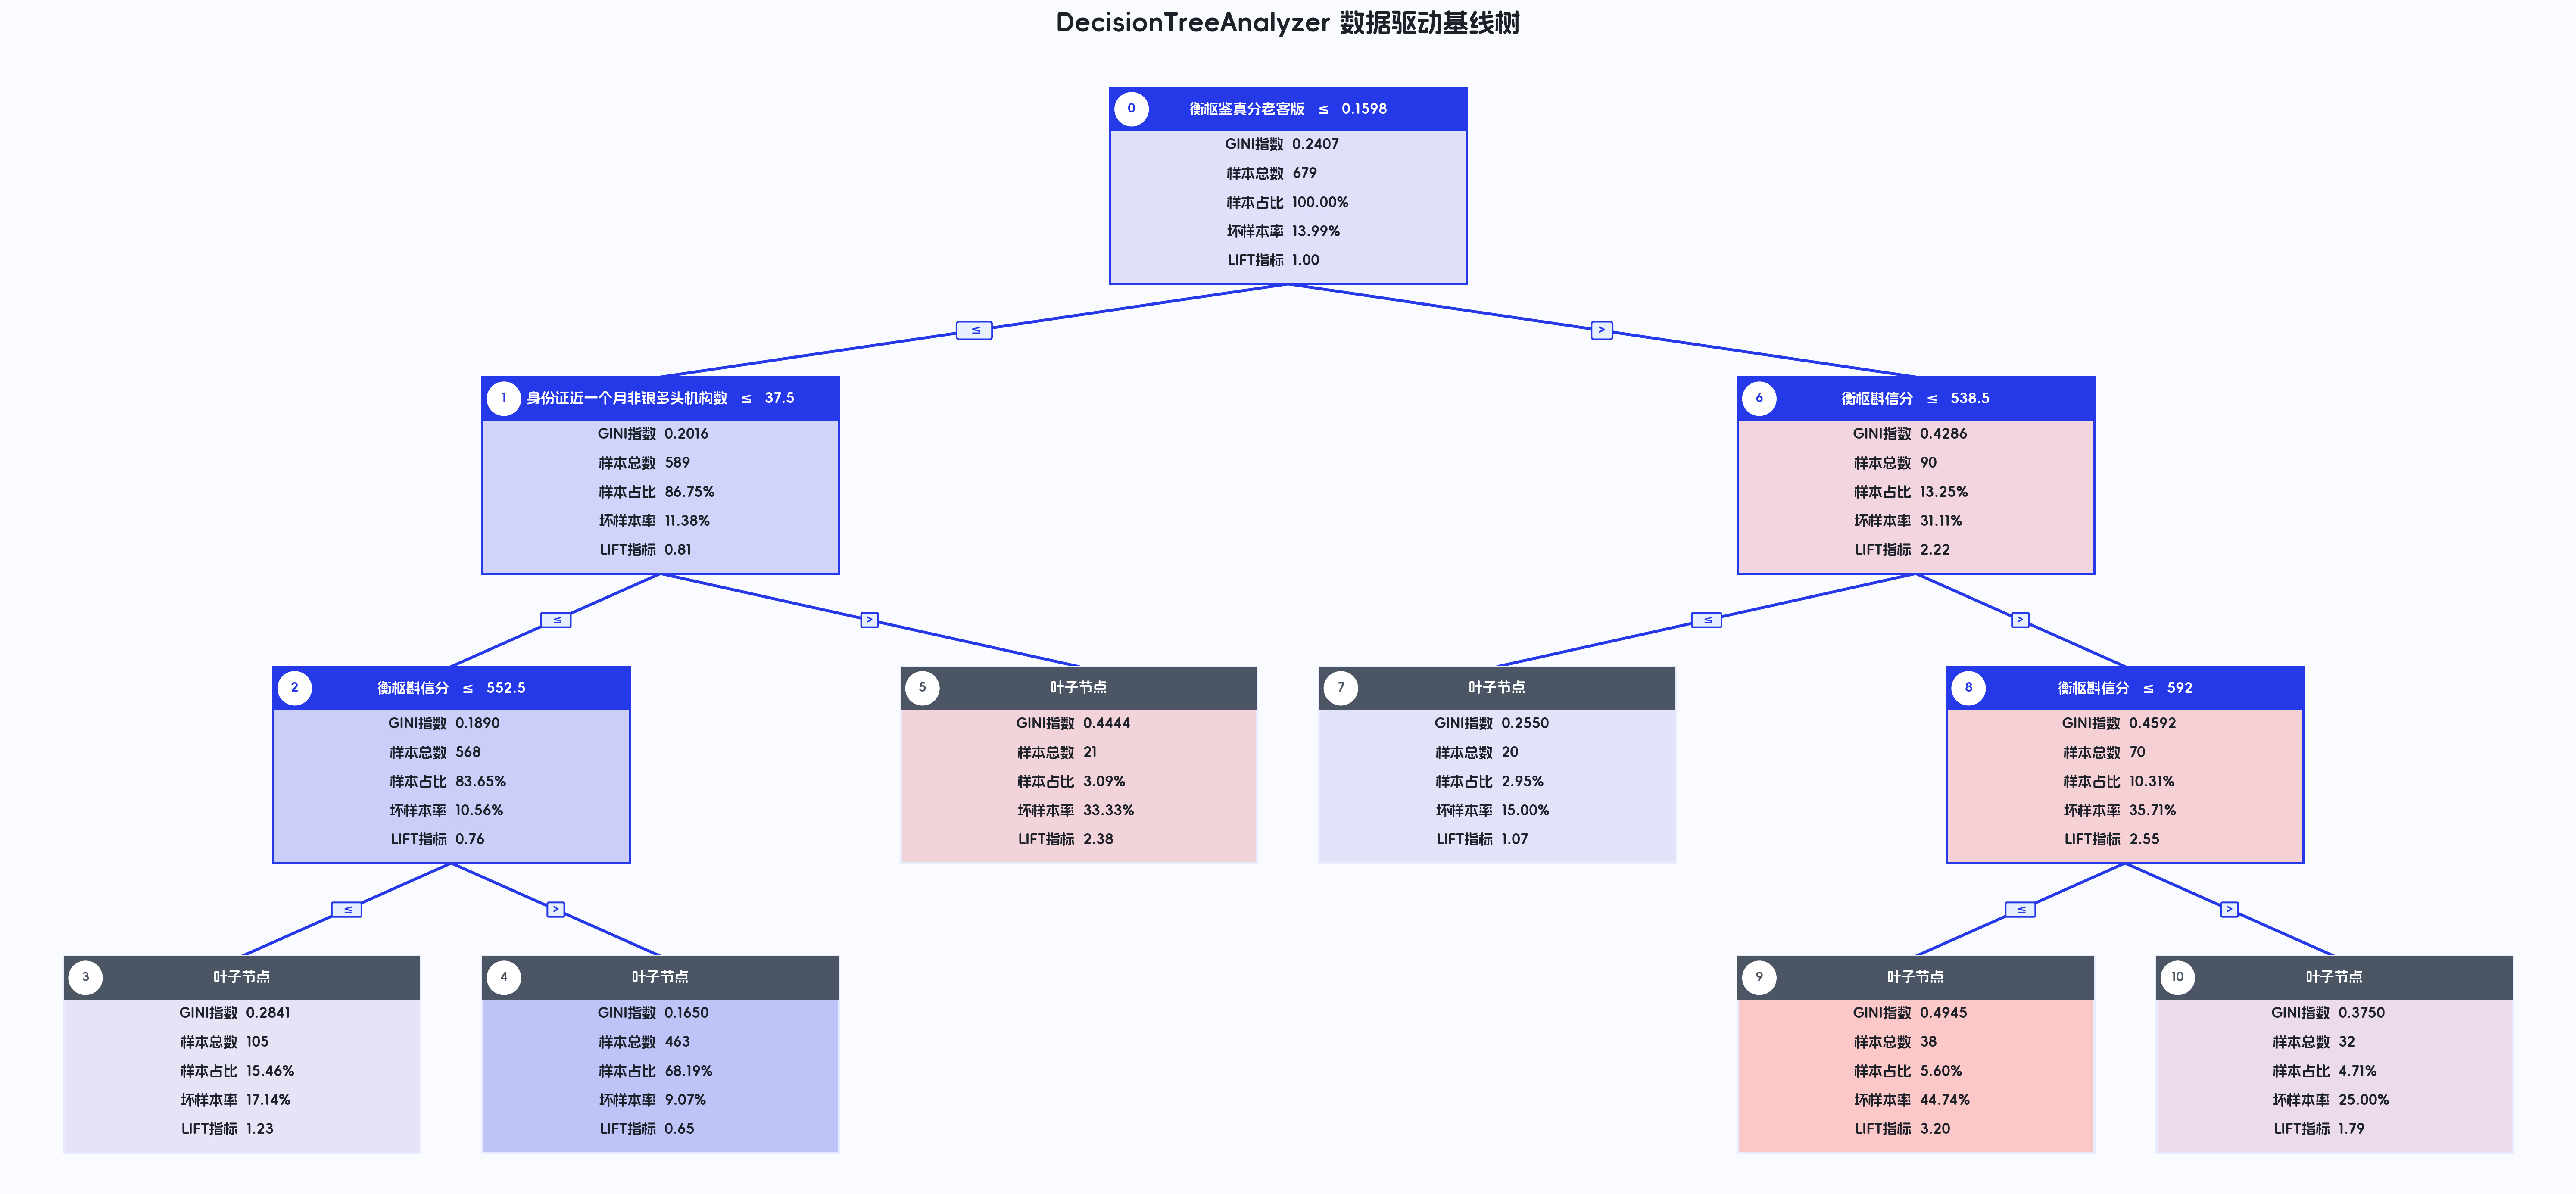

In [7]:
fig = plot_tree(
    analyzer,
    backend="matplotlib",
    save=str(OUTPUT_DIR / "01_decision_tree_analyzer.png"),
    title="DecisionTreeAnalyzer 数据驱动基线树",
)
plt.show()


**图 1：数据驱动基线树**

![DecisionTreeAnalyzer 数据驱动基线树](../../examples/model_report/manual_tree_rule_mining/01_decision_tree_analyzer.png)


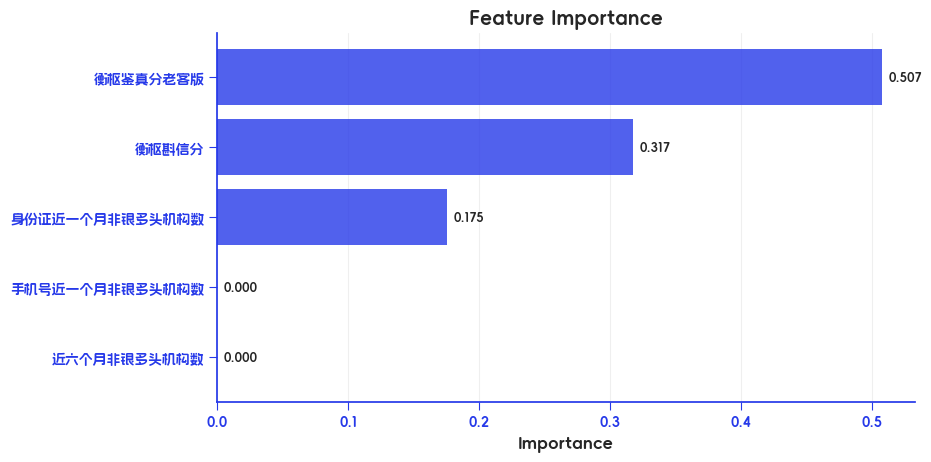

In [8]:
fig = feature_importance_plot(
    features=feature_list,
    importance=analyzer.clf.feature_importances_,
    top_n=len(feature_list),
    figsize=(9, 4.8),
    save=str(OUTPUT_DIR / "02_decision_tree_feature_importance.png"),
)
plt.show()


**图 2：决策树特征重要性**

![决策树特征重要性](../../examples/model_report/manual_tree_rule_mining/02_decision_tree_feature_importance.png)


## 3. 批量候选规则：TreeRuleExtractor

`TreeRuleExtractor` 更像“候选规则生产器”。它可以从单棵树、随机森林、GBDT 等树模型中提取路径规则，并用 `Rule.report` 回填命中样本数、坏样本率、LIFT 和坏账改善。

在策略开发中，它适合用来扩大候选池；最终是否进入策略，仍应回到 `Rule.report` 和业务解释。


In [9]:
extractor_results = []
for algorithm in ["dt", "rf", "gbdt"]:
    extractor = TreeRuleExtractor(
        algorithm=algorithm,
        target=target,
        max_depth=3,
        min_samples_split=50,
        min_samples_leaf=20,
        n_estimators=5,
        random_state=42,
    )
    extractor.fit(df_train[feature_list + [target]])
    extractor.extract_rules()
    table = extractor.get_rules_dataframe(
        top_n=8,
        datasets=df_test[feature_list + [target]],
        target=target,
        min_samples=15,
    )
    if len(table):
        table.insert(0, "算法", algorithm)
        extractor_results.append(table)

candidate_rules = pd.concat(extractor_results, ignore_index=True)
candidate_rules.sort_values(["命中LIFT值", "命中样本数"], ascending=[False, False]).head(12)


,算法,规则编号,规则表达式,命中样本数,命中样本占比,命中坏样本率,命中LIFT值,坏账改善,风险拒绝比
1,dt,4,(衡枢鉴真分老客版 > 0.1584794893860817) & (衡枢斟信分 > 570.5),16,0.0550,0.3750,2.6616,0.0967,1.7583
18,gbdt,1,(手机号近一个月非银多头机构数 <= 37.5) & (衡枢斟信分 <= 642.5) & (衡枢鉴真分老客版 > 0.1584794893860817),22,0.0756,0.3182,2.2583,0.1029,1.3612
10,rf,3,(衡枢鉴真分老客版 > 0.1584794893860817),30,0.1031,0.3000,2.1293,0.1298,1.2591
20,gbdt,2,(手机号近一个月非银多头机构数 <= 37.5) & (衡枢鉴真分老客版 > 0.1584794893860817) & (手机号近一个月非银多头机构数 <= 26.5),19,0.0653,0.2632,1.8678,0.0606,0.9284
11,rf,3,(近六个月非银多头机构数 > 74.5),46,0.1581,0.2174,1.5429,0.1019,0.6449
4,dt,3,(衡枢鉴真分老客版 > 0.1584794893860817) & (衡枢斟信分 <= 570.5),14,0.0481,0.2143,1.5209,0.0263,0.5472
3,dt,2,(衡枢鉴真分老客版 <= 0.1584794893860817) & (手机号近一个月非银多头机构数 > 36.5),16,0.0550,0.1875,1.3308,0.0192,0.3500
12,rf,4,(近六个月非银多头机构数 > 78.5),28,0.0962,0.1786,1.2674,0.0285,0.2959
14,gbdt,1,(身份证近一个月非银多头机构数 <= 37.5) & (衡枢斟信分 <= 607.5) & (身份证近一个月非银多头机构数 > 13.5),127,0.4364,0.1575,1.1177,0.0912,0.2089
5,rf,1,(近六个月非银多头机构数 <= 78.5) & (衡枢斟信分 <= 642.5) & (身份证近一个月非银多头机构数 > 15.5),152,0.5223,0.1447,1.0273,0.0298,0.0571


**运行结果：TreeRuleExtractor 候选规则 Top 12**

| 算法 | 规则编号 | 规则表达式 | 命中样本数 | 命中样本占比 | 命中坏样本率 | 命中LIFT值 | 坏账改善 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| dt | 4 | (衡枢鉴真分老客版 > 0.1584794893860817)<br>& (衡枢斟信分 > 570.5) | 16 | 5.50% | 37.50% | 2.6616 | 0.0967 | 1.7583 |
| gbdt | 1 | (手机号近一个月非银多头机构数 <= 37.5)<br>& (衡枢斟信分 <= 642.5)<br>& (衡枢鉴真分老客版 > 0.1584794893860817) | 22 | 7.56% | 31.82% | 2.2583 | 0.1029 | 1.3612 |
| rf | 3 | (衡枢鉴真分老客版 > 0.1584794893860817) | 30 | 10.31% | 30.00% | 2.1293 | 0.1298 | 1.2591 |
| gbdt | 2 | (手机号近一个月非银多头机构数 <= 37.5)<br>& (衡枢鉴真分老客版 > 0.1584794893860817)<br>& (手机号近一个月非银多头机构数 <= 26.5) | 19 | 6.53% | 26.32% | 1.8678 | 0.0606 | 0.9284 |
| rf | 3 | (近六个月非银多头机构数 > 74.5) | 46 | 15.81% | 21.74% | 1.5429 | 0.1019 | 0.6449 |
| dt | 3 | (衡枢鉴真分老客版 > 0.1584794893860817)<br>& (衡枢斟信分 <= 570.5) | 14 | 4.81% | 21.43% | 1.5209 | 0.0263 | 0.5472 |
| dt | 2 | (衡枢鉴真分老客版 <= 0.1584794893860817)<br>& (手机号近一个月非银多头机构数 > 36.5) | 16 | 5.50% | 18.75% | 1.3308 | 0.0192 | 0.3500 |
| rf | 4 | (近六个月非银多头机构数 > 78.5) | 28 | 9.62% | 17.86% | 1.2674 | 0.0285 | 0.2959 |
| gbdt | 1 | (身份证近一个月非银多头机构数 <= 37.5)<br>& (衡枢斟信分 <= 607.5)<br>& (身份证近一个月非银多头机构数 > 13.5) | 127 | 43.64% | 15.75% | 1.1177 | 0.0912 | 0.2089 |
| rf | 1 | (近六个月非银多头机构数 <= 78.5)<br>& (衡枢斟信分 <= 642.5)<br>& (身份证近一个月非银多头机构数 > 15.5) | 152 | 52.23% | 14.47% | 1.0273 | 0.0298 | 0.0571 |
| rf | 2 | (近六个月非银多头机构数 <= 74.5)<br>& (衡枢斟信分 > 504.5)<br>& (手机号近一个月非银多头机构数 > 12.5) | 204 | 70.10% | 14.22% | 1.0090 | 0.0210 | 0.0300 |
| gbdt | 3 | (身份证近一个月非银多头机构数 <= 37.5)<br>& (衡枢斟信分 > 607.5)<br>& (衡枢斟信分 > 622.5) | 101 | 34.71% | 13.86% | 0.9838 | -0.0086 | -0.0248 |


自动规则候选表的重点是“发现方向”，不是机械复制表达式。比如某条规则在测试集上 LIFT 较高，但命中样本少；另一条规则覆盖较大，但 LIFT 只是略高于 1。前者可以进入强规则候选，后者更适合作为组合策略或分层策略的一部分。

## 4. 人工决策树：ManualTreeExtractor 的核心价值

自动树解决“数据怎么切”的问题，人工树解决“规则怎么被业务接受”的问题。

`ManualTreeExtractor` 的关键设计是：人工修改树结构后，规则表、图形和 `Rule` 对象都会基于最新树结构重新生成。也就是说，业务专家不是在 PPT 上改阈值，而是在可执行对象上改树；每次改动都能立刻回算样本、坏账率、LIFT、风险拒绝比和规则表达式。

下面从一棵浅树开始，然后把根节点改为业务认可的 `衡枢斟信分 <= 600`。


In [10]:
manual_tree = ManualTreeExtractor(
    target=target,
    max_depth=2,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
manual_tree.fit(df_train, features=feature_list)

manual_base_leaf = manual_tree.get_rule_table(leaf_only=True)
manual_base_leaf[
    ["节点编号", "指标含义", "样本总数", "样本占比", "坏样本率", "LIFT值", "风险拒绝比"]
].sort_values("LIFT值", ascending=False)


,节点编号,指标含义,样本总数,样本占比,坏样本率,LIFT值,风险拒绝比
3,6,衡枢斟信分 > 538.5000(含缺失) 且 衡枢鉴真分老客版 > 0.1598,70,0.1031,0.3571,2.5526,1.7311
1,3,衡枢鉴真分老客版 <= 0.1598(含缺失) 且 身份证近一个月非银多头机构数 > 37.5000,21,0.0309,0.3333,2.3825,1.4266
2,5,衡枢斟信分 <= 538.5000 且 衡枢鉴真分老客版 > 0.1598,20,0.0295,0.1500,1.0721,0.0743
0,2,衡枢鉴真分老客版 <= 0.1598(含缺失) 且 身份证近一个月非银多头机构数 <= 37.5000(含缺失),568,0.8365,0.1056,0.7550,-1.4987


**运行结果：人工干预前的基础树叶节点**

| 节点编号 | 指标含义 | 样本总数 | 样本占比 | 坏样本率 | LIFT值 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- |
| 6 | 衡枢斟信分 > 538.5000(含缺失)<br>衡枢鉴真分老客版 > 0.1598 | 70 | 10.31% | 35.71% | 2.5526 | 1.7311 |
| 3 | 衡枢鉴真分老客版 <= 0.1598(含缺失)<br>身份证近一个月非银多头机构数 > 37.5000 | 21 | 3.09% | 33.33% | 2.3825 | 1.4266 |
| 5 | 衡枢斟信分 <= 538.5000<br>衡枢鉴真分老客版 > 0.1598 | 20 | 2.95% | 15.00% | 1.0721 | 0.0743 |
| 2 | 衡枢鉴真分老客版 <= 0.1598(含缺失)<br>身份证近一个月非银多头机构数 <= 37.5000(含缺失) | 568 | 83.65% | 10.56% | 0.7550 | -1.4987 |


In [11]:
manual_tree.manual_split(
    data=df_train,
    feature="衡枢斟信分",
    threshold=600,
    node=0,
)

manual_root_leaf = manual_tree.get_rule_table(leaf_only=True)
manual_root_leaf[["节点编号", "指标含义", "样本总数", "样本占比", "坏样本率", "LIFT值", "风险拒绝比"]]


,节点编号,指标含义,样本总数,样本占比,坏样本率,LIFT值,风险拒绝比
0,1,衡枢斟信分 <= 600.0000,328,0.4831,0.1829,1.3074,0.5947
1,2,衡枢斟信分 > 600.0000(含缺失),351,0.5169,0.0997,0.7127,-0.5947


**运行结果：根节点改为 600 分后的两层客群**

| 节点编号 | 指标含义 | 样本总数 | 样本占比 | 坏样本率 | LIFT值 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 衡枢斟信分 <= 600.0000 | 328 | 48.31% | 18.29% | 1.3074 | 0.5947 |
| 2 | 衡枢斟信分 > 600.0000(含缺失) | 351 | 51.69% | 9.97% | 0.7127 | -0.5947 |


根节点改为 600 分后，树被重构为两个可解释客群：低于等于 600 分和高于 600 分。这个阈值未必是统计最优，但它更容易沟通、上线和监控。随后可以在不同客群内继续使用不同变量，这正是信贷策略分层的常见逻辑。


In [12]:
# 在低分客群中继续看中期多头；在高分客群中让算法为风险分自动寻找阈值
manual_tree.manual_split(
    data=df_train,
    feature="近六个月非银多头机构数",
    threshold=55,
    node=1,
)
manual_tree.manual_split(
    data=df_train,
    feature="衡枢鉴真分老客版",
    threshold=None,
    node=2,
)

manual_train_leaf = manual_tree.get_rule_table(df_train, leaf_only=True)
manual_test_leaf = manual_tree.get_rule_table(df_test, leaf_only=True)

manual_train_leaf[
    ["节点编号", "指标含义", "样本总数", "样本占比", "坏样本率", "LIFT值", "风险拒绝比"]
].sort_values("节点编号")


,节点编号,指标含义,样本总数,样本占比,坏样本率,LIFT值,风险拒绝比
0,3,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000,108,0.1591,0.1481,1.0589,0.0700
1,4,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失),220,0.3240,0.2000,1.4295,0.6353
2,5,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 <= 0.1649,329,0.4845,0.0851,0.6083,-0.7599
3,6,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失),22,0.0324,0.3182,2.2742,1.3168


**运行结果：人工树训练集叶节点**

| 节点编号 | 指标含义 | 样本总数 | 样本占比 | 坏样本率 | LIFT值 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 | 108 | 15.91% | 14.81% | 1.0589 | 0.0700 |
| 4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) | 220 | 32.40% | 20.00% | 1.4295 | 0.6353 |
| 5 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 <= 0.1649 | 329 | 48.45% | 8.51% | 0.6083 | -0.7599 |
| 6 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) | 22 | 3.24% | 31.82% | 2.2742 | 1.3168 |


In [13]:
manual_test_leaf[
    ["节点编号", "指标含义", "样本总数", "样本占比", "坏样本率", "LIFT值", "风险拒绝比"]
].sort_values("节点编号")


,节点编号,指标含义,样本总数,样本占比,坏样本率,LIFT值,风险拒绝比
0,3,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000,44,0.1512,0.1591,1.1292,0.1522
1,4,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失),100,0.3436,0.1300,0.9227,-0.1178
2,5,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 <= 0.1649,136,0.4674,0.1324,0.9394,-0.1138
3,6,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失),11,0.0378,0.2727,1.9357,0.9725


**运行结果：人工树测试集叶节点**

| 节点编号 | 指标含义 | 样本总数 | 样本占比 | 坏样本率 | LIFT值 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 | 44 | 15.12% | 15.91% | 1.1292 | 0.1522 |
| 4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) | 100 | 34.36% | 13.00% | 0.9227 | -0.1178 |
| 5 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 <= 0.1649 | 136 | 46.74% | 13.24% | 0.9394 | -0.1138 |
| 6 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) | 11 | 3.78% | 27.27% | 1.9357 | 0.9725 |


训练集和测试集对照是规则开发中最重要的一步。一个节点在训练集 LIFT 高、测试集也保持高风险方向，才有进一步讨论价值；如果训练集很强、测试集失效，更可能是样本偶然性或节点过细。这里节点 4 在训练集 LIFT 为 1.43，但测试集回落到 0.92，不应直接进入最终策略；节点 6 在训练集 LIFT 为 2.27、测试集仍有 1.94，虽然覆盖小，但风险方向更稳定，更适合进入强风险复核规则池。


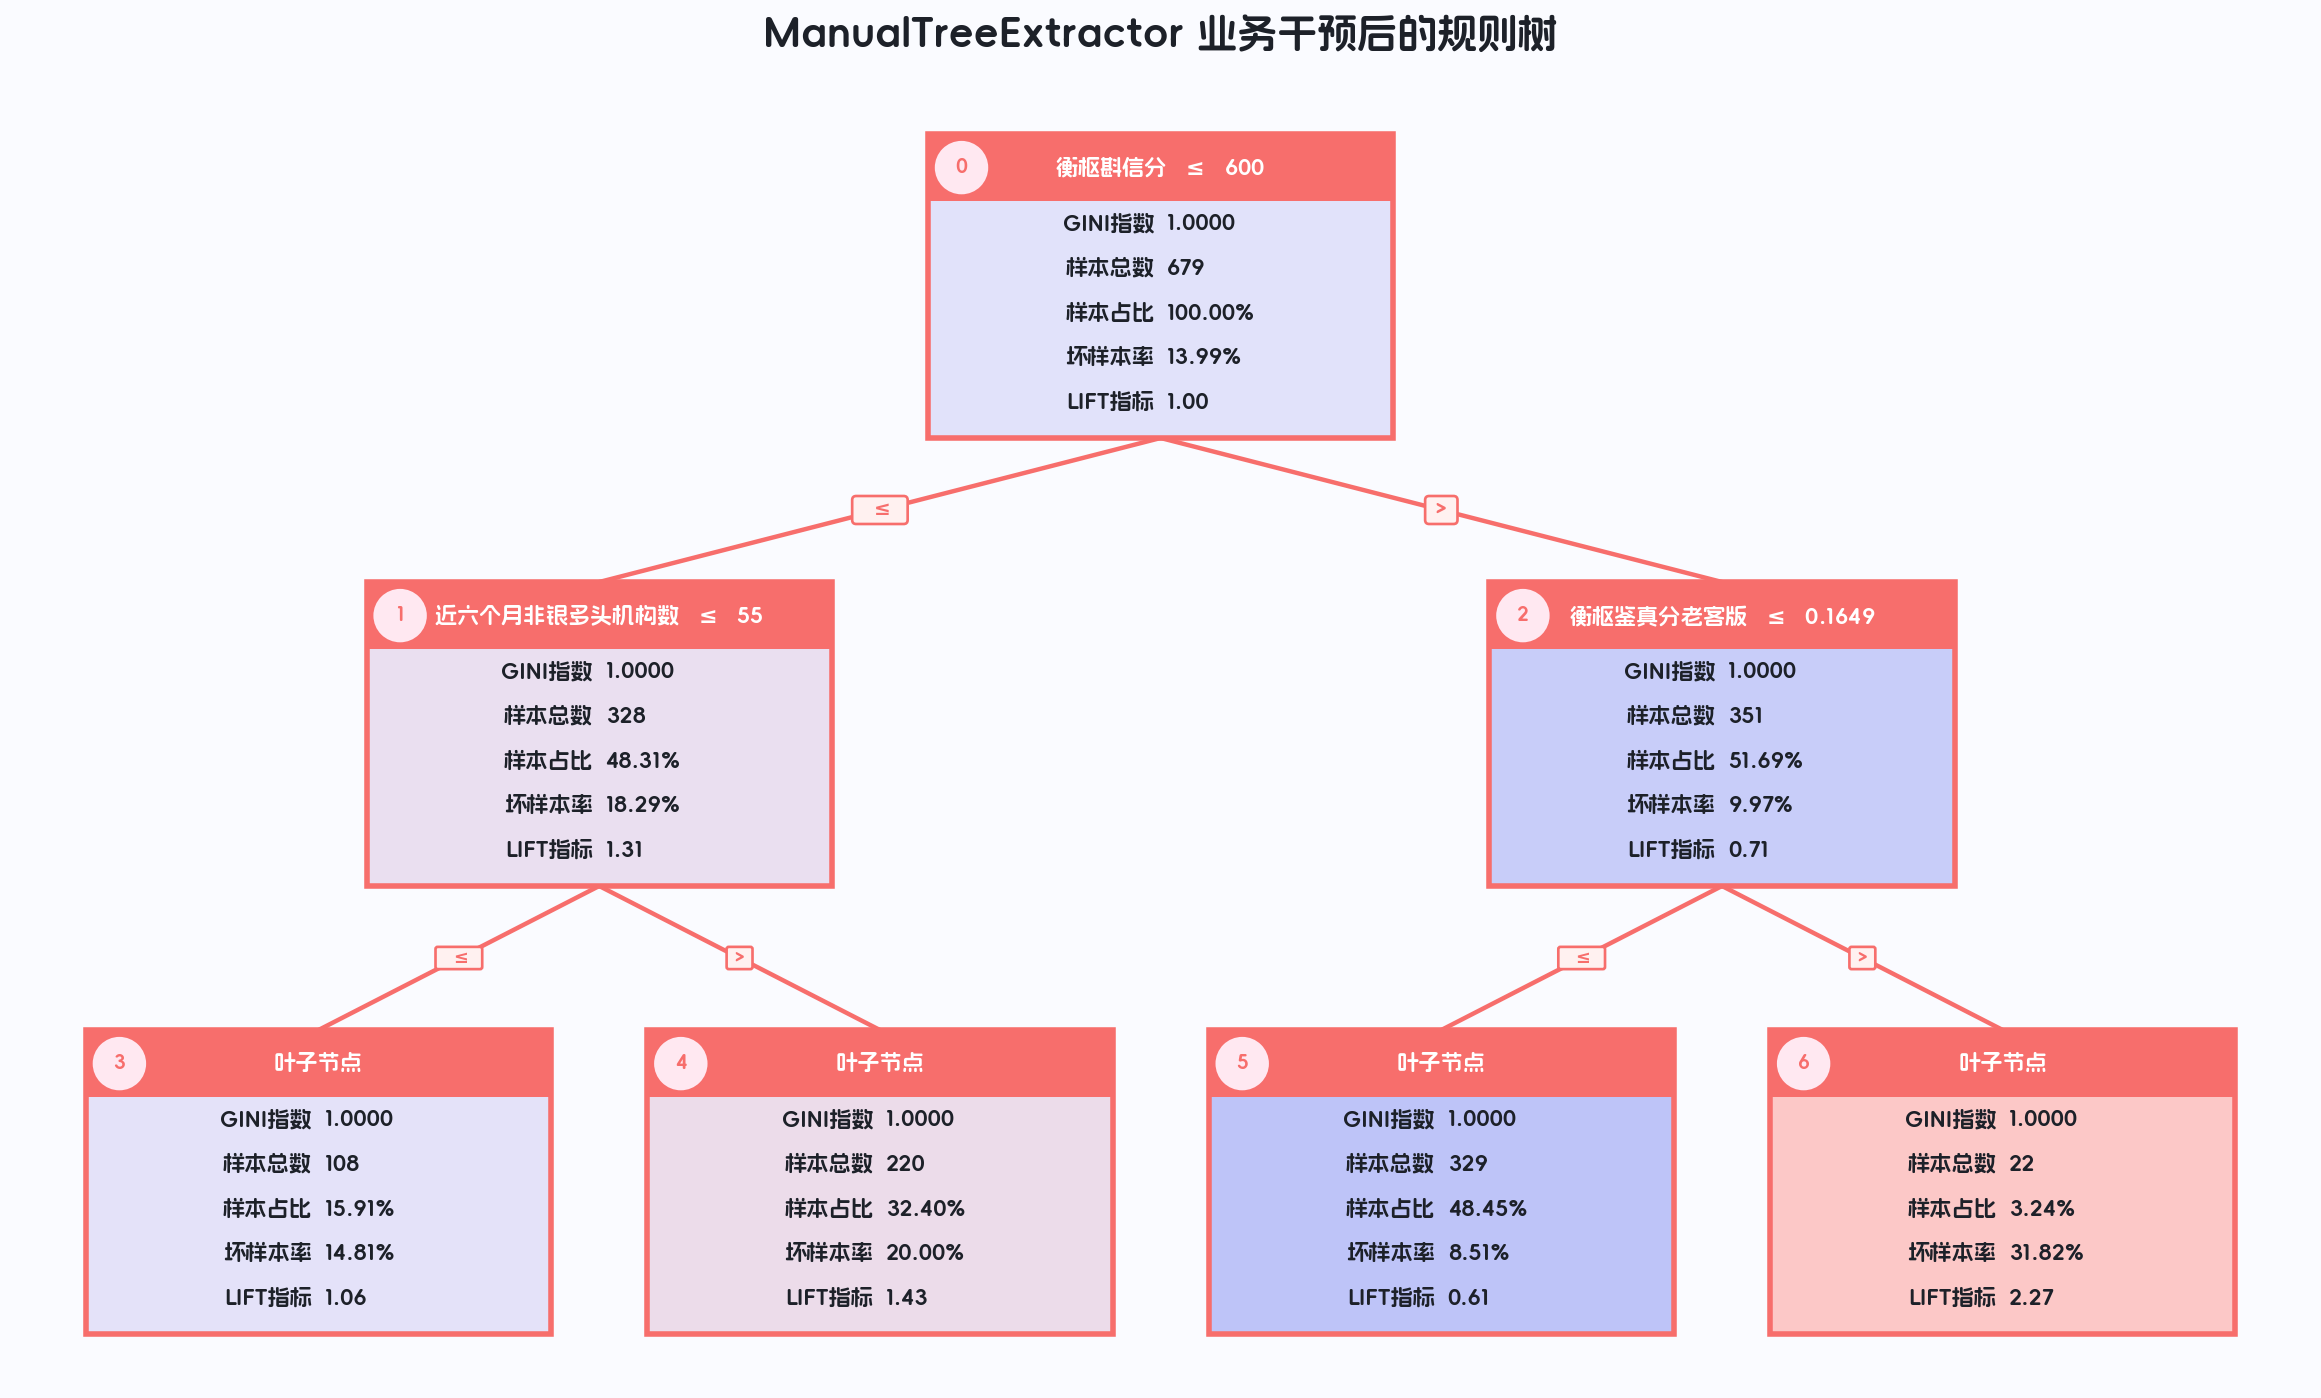

In [14]:
fig = plot_tree_matplotlib(
    manual_tree,
    figsize=(18, 12),
    dpi=160,
    save=str(OUTPUT_DIR / "03_manual_tree_business_split.png"),
    title="ManualTreeExtractor 业务干预后的规则树",
)
plt.show()


**图 3：业务干预后的人工规则树**

![ManualTreeExtractor 业务干预后的规则树](../../examples/model_report/manual_tree_rule_mining/03_manual_tree_business_split.png)


## 5. 三种决策树画图方式

`hscredit.core.viz.plot_tree` 支持三类输出：

| 后端 | 适用场景 |
|---|---|
| `matplotlib` | notebook 快速预览、文章静态图片 |
| `pyecharts` | 交互式 HTML，适合策略评审会缩放查看 |
| `graphviz` | PDF/SVG/PNG，高质量报告归档 |

人工修改过的节点会在图中用副主题色标记，便于区分数据自动分裂和业务干预分裂。


图形文件已保存至： /Users/xiaoxi/Desktop/itlubber/model_platform_codebuddy/hscredit/examples/model_report/manual_tree_rule_mining


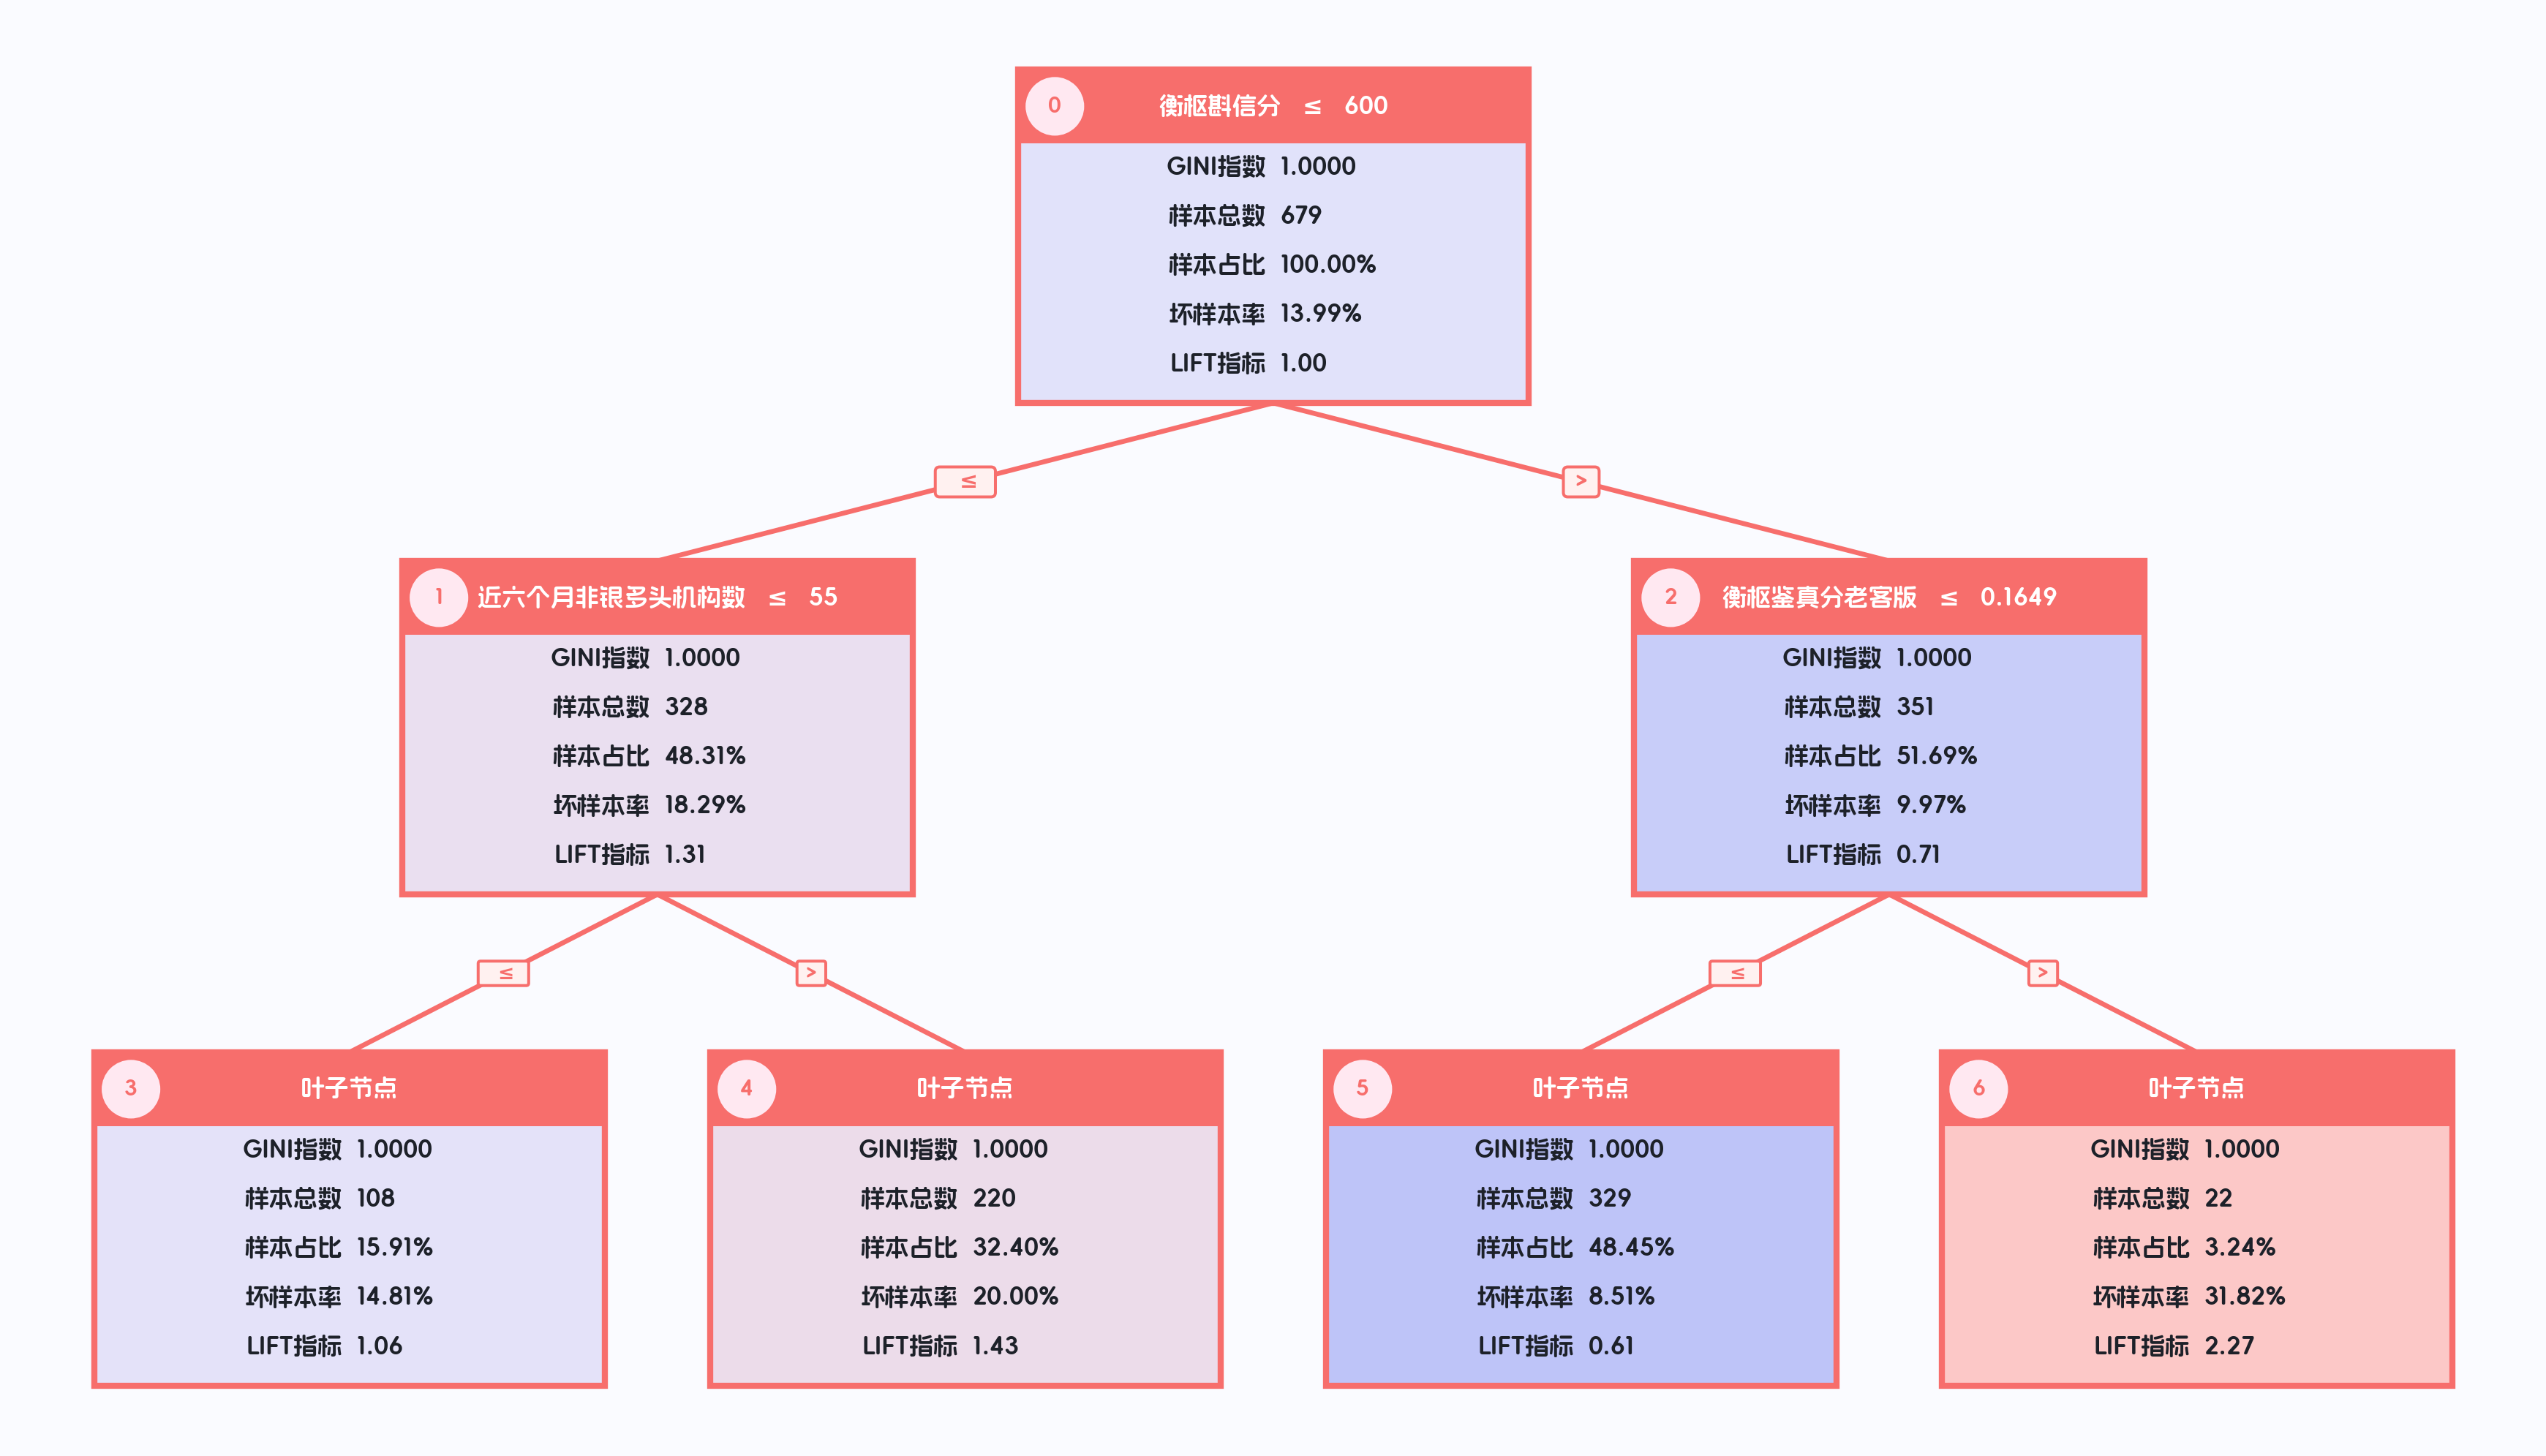

In [15]:
# 统一入口：同一棵树可切换不同渲染后端
plot_tree(manual_tree, backend="matplotlib", save=str(OUTPUT_DIR / "04_plot_tree_unified.png"))
chart = plot_tree_pyecharts(
    manual_tree,
    title="交互式人工决策树规则图",
    save=str(OUTPUT_DIR / "05_manual_tree_interactive.html"),
    width="1400px",
    height="900px",
)
src = plot_tree_graphviz(
    manual_tree,
    save=str(OUTPUT_DIR / "06_manual_tree_graphviz.pdf"),
    figsize=(12, 8),
    dpi=150,
)
plot_tree_graphviz(
    manual_tree,
    save=str(OUTPUT_DIR / "06_manual_tree_graphviz.png"),
    figsize=(12, 8),
    dpi=150,
)

print("图形文件已保存至：", OUTPUT_DIR)


**图 4：统一 plot_tree 输出**

![统一 plot_tree 输出](../../examples/model_report/manual_tree_rule_mining/04_plot_tree_unified.png)

交互式 HTML：[05_manual_tree_interactive.html](../../examples/model_report/manual_tree_rule_mining/05_manual_tree_interactive.html)；Graphviz PDF：[06_manual_tree_graphviz.pdf](../../examples/model_report/manual_tree_rule_mining/06_manual_tree_graphviz.pdf)。

**图 4-2：Graphviz 高质量归档版预览**

![Graphviz 高质量决策树预览](../../examples/model_report/manual_tree_rule_mining/06_manual_tree_graphviz.png)


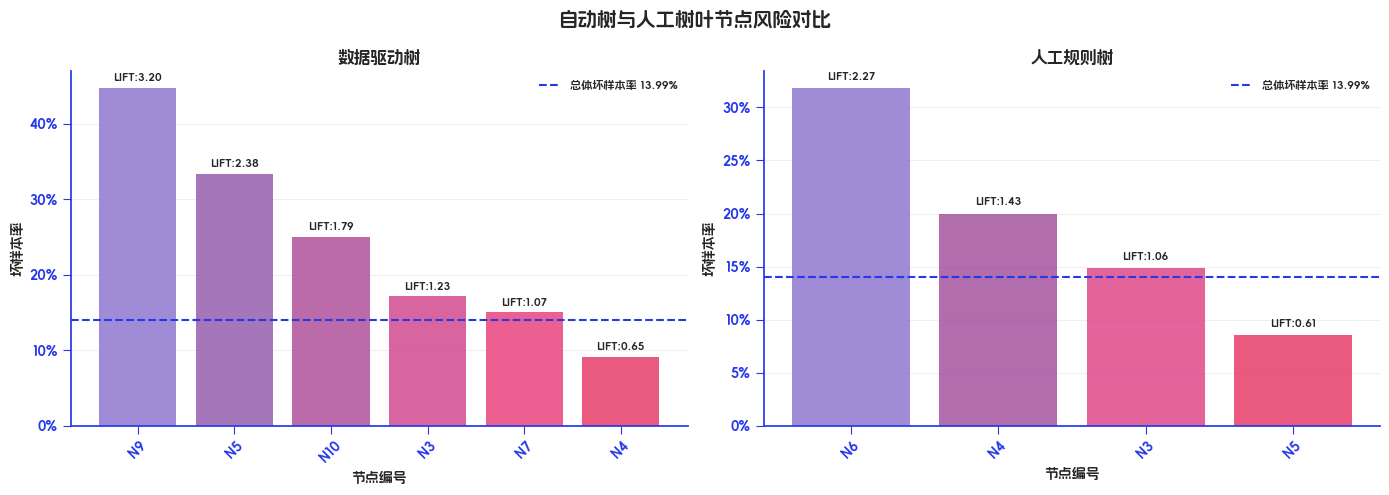

In [16]:
fig = tree_leaf_comparison_plot(
    {
        "数据驱动树": auto_leaf,
        "人工规则树": manual_train_leaf,
    },
    overall_bad_rate=df_train[target].mean(),
    title="自动树与人工树叶节点风险对比",
    save=str(OUTPUT_DIR / "07_auto_vs_manual_leaf_comparison.png"),
)
plt.show()


**图 5：自动树与人工树叶节点风险对比**

![自动树与人工树叶节点风险对比](../../examples/model_report/manual_tree_rule_mining/07_auto_vs_manual_leaf_comparison.png)


`tree_leaf_comparison_plot` 适合回答一个很现实的问题：人工调整后，规则树是否牺牲了太多风险区分度？如果人工树在可解释性提升的同时，高风险叶子仍能保持较好的 LIFT 和覆盖面，说明业务经验与数据证据达成了较好的平衡。

## 6. 剪枝与节点删除：控制复杂度

自动树容易切出样本很小的叶子。对于上线策略，过细节点会带来三类问题：稳定性差、解释成本高、监控成本高。`delete_node()` 可以把指定节点及其子树删除，让该节点重新成为叶子。

下面复制一棵树，演示删除节点后的规则表变化。


In [17]:
pruned_tree = ManualTreeExtractor(
    target=target,
    max_depth=4,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
pruned_tree.fit(df_train, features=feature_list)
pruned_tree.manual_split(df_train, feature="衡枢斟信分", threshold=600, node=0)
pruned_tree.manual_split(df_train, feature="近六个月非银多头机构数", threshold=55, node=1)
pruned_tree.manual_split(df_train, feature="衡枢鉴真分老客版", threshold=None, node=2)

before_delete = pruned_tree.get_rule_table(leaf_only=True)[["节点编号", "指标含义", "样本总数", "坏样本率", "LIFT值"]]
pruned_tree.delete_node(node=2)
after_delete = pruned_tree.get_rule_table(leaf_only=True)[["节点编号", "指标含义", "样本总数", "坏样本率", "LIFT值"]]

print("删除前叶子数：", len(before_delete), "删除后叶子数：", len(after_delete))
after_delete


删除前叶子数： 4 删除后叶子数： 3


,节点编号,指标含义,样本总数,坏样本率,LIFT值
0,2,衡枢斟信分 > 600.0000(含缺失),351,0.0997,0.7127
1,3,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000,108,0.1481,1.0589
2,4,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失),220,0.2000,1.4295


**运行结果：删除节点后的叶子规则表**

删除前叶子数：4；删除后叶子数：3。

| 节点编号 | 指标含义 | 样本总数 | 坏样本率 | LIFT值 |
| --- | --- | --- | --- | --- |
| 2 | 衡枢斟信分 > 600.0000(含缺失) | 351 | 9.97% | 0.7127 |
| 3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 | 108 | 14.81% | 1.0589 |
| 4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) | 220 | 20.00% | 1.4295 |


剪枝不是“弱化模型”，而是把策略复杂度控制在可解释、可部署、可监控的范围内。金融规则尤其需要避免过度依赖小样本节点。

## 7. 节点规则报告：target、DPD、金额、时间外样本

`ManualTreeExtractor.report()` 与 `get_rule_table()` 使用同一套底层逻辑：把节点路径转成 `Rule`，再调用 `Rule.report`，最后汇总“命中”行。因此节点样本数和坏账率是规则真实命中的结果，不是树对象内部数组的机械展示。

这让我们可以在多个业务口径下复用同一棵树。


In [18]:
# 多数据集：训练集、测试集、按月份切分的时间样本
month_datasets = {
    f"月份_{month}": group.copy()
    for month, group in data.groupby("放款月份")
    if len(group) >= 80
}
all_reports = manual_tree.report(
    {"训练集": df_train, "测试集": df_test, **month_datasets},
    target=target,
    leaf_only=True,
)

# 汇总每个数据集最高 LIFT 叶子，快速判断时间稳定性
stability_rows = []
for name, table in all_reports.items():
    top = table.sort_values("LIFT值", ascending=False).iloc[0]
    stability_rows.append({
        "样本集": name,
        "最高LIFT节点": int(top["节点编号"]),
        "样本总数": int(top["样本总数"]),
        "坏样本率": top["坏样本率"],
        "LIFT值": top["LIFT值"],
    })

pd.DataFrame(stability_rows)


,样本集,最高LIFT节点,样本总数,坏样本率,LIFT值
0,训练集,6,22,0.3182,2.2742
1,测试集,6,11,0.2727,1.9357
2,月份_2025-11,6,14,0.2143,1.4670
3,月份_2025-12,6,12,0.4167,2.8557
4,月份_2026-01,6,5,0.4000,2.1714
5,月份_2026-02,4,55,0.1091,1.3164


**运行结果：跨样本最高风险节点稳定性**

| 样本集 | 最高LIFT节点 | 样本总数 | 坏样本率 | LIFT值 |
| --- | --- | --- | --- | --- |
| 训练集 | 6 | 22 | 31.82% | 2.2742 |
| 测试集 | 6 | 11 | 27.27% | 1.9357 |
| 月份_2025-11 | 6 | 14 | 21.43% | 1.4670 |
| 月份_2025-12 | 6 | 12 | 41.67% | 2.8557 |
| 月份_2026-01 | 6 | 5 | 40.00% | 2.1714 |
| 月份_2026-02 | 4 | 55 | 10.91% | 1.3164 |


In [19]:
# 多逾期口径：同一套节点规则，同时看 DPD7、DPD3、DPD0
multi_dpd_report = manual_tree.report(
    df_test,
    overdue=["MOB1"],
    dpds=[7, 3, 0],
    leaf_only=True,
)
multi_dpd_report.head()


分箱详情                                                                                                                                                                               MOB1 7+                                                                              MOB1 3+                                                                              MOB1 0+                                                                             
  节点编号 是否叶子  规则分类                                                                                               指标名称                                            指标含义  分箱 样本总数   样本占比    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善   风险拒绝比    准确率    精确率    召回率   F1分数    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善   风险拒绝比    准确率    精确率    召回率   F1分数    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善   风险拒绝比    准确率    精确率    召回率   F1分数
0    3    是  验证规则                                                           (衡枢斟信分 <= 600.0) & (近六个月非银多头机构数 <= 55.0)      衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000  命中   44 0.1512      36 0.1469    8 0.1739 0.1818 1.1502  0.0268  0.1770 0.7457 0.1818 0.1739 0.1778      35 0.1458    9 0.1765 0.2045 1.1671  0.0298  0.1969 0.7354 0.2045 0.1765 0.1895      33 0.1422   11 0.1864 0.2500 1.2331  0.0415  0.2746 0.7216 0.2500 0.1864 0.2136
1    4    是  验证规则                           (衡枢斟信分 <= 600.0) & ((近六个月非银多头机构数 > 55.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数))  衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失)  命中  100 0.3436      85 0.3469   15 0.3261 0.1500 0.9489 -0.0267 -0.0778 0.6014 0.1500 0.3261 0.2055      82 0.3417   18 0.3529 0.1800 1.0271  0.0142  0.0412 0.6048 0.1800 0.3529 0.2384      80 0.3448   20 0.3390 0.2000 0.9864 -0.0071 -0.0207 0.5911 0.2000 0.3390 0.2516
2    5    是  验证规则                            ((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & (衡枢鉴真分老客版 <= 0.1648675501346588)      衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 <= 0.1649  命中  136 0.4674     116 0.4735   20 0.4348 0.1471 0.9303 -0.0612 -0.1308 0.5120 0.1471 0.4348 0.2198     115 0.4792   21 0.4118 0.1544 0.8811 -0.1044 -0.2233 0.5017 0.1544 0.4118 0.2246     111 0.4784   25 0.4237 0.1838 0.9067 -0.0819 -0.1752 0.5017 0.1838 0.4237 0.2564
3    6    是  验证规则  ((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))  衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失)  命中   11 0.0378       8 0.0327    3 0.0652 0.2727 1.7253  0.0285  0.7538 0.8247 0.2727 0.0652 0.1053       8 0.0333    3 0.0588 0.2727 1.5561  0.0218  0.5780 0.8076 0.2727 0.0588 0.0968       8 0.0345    3 0.0508 0.2727 1.3451  0.0136  0.3587 0.7801 0.2727 0.0508 0.0857

**运行结果：多 DPD 口径规则表现**

| 节点编号 | 指标含义 | DPD7坏样本率 | DPD7 LIFT | DPD3坏样本率 | DPD3 LIFT | DPD0坏样本率 | DPD0 LIFT |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 | 18.18% | 1.1502 | 20.45% | 1.1671 | 25.00% | 1.2331 |
| 4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) | 15.00% | 0.9489 | 18.00% | 1.0271 | 20.00% | 0.9864 |
| 5 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 <= 0.1649 | 14.71% | 0.9303 | 15.44% | 0.8811 | 18.38% | 0.9067 |
| 6 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) | 27.27% | 1.7253 | 27.27% | 1.5561 | 27.27% | 1.3451 |


In [20]:
# 金额口径：命中人数之外，还要看命中风险敞口
amount_report = manual_tree.report(
    df_test,
    target=target,
    amount="放款金额",
    leaf_only=True,
)
amount_report[["节点编号", "指标含义", "样本总数", "样本占比", "坏样本率", "LIFT值", "风险拒绝比"]]


,节点编号,指标含义,样本总数,样本占比,坏样本率,LIFT值,风险拒绝比
0,3,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000,164472,0.1324,0.1620,1.0789,0.0909
1,4,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失),361857,0.2913,0.1187,0.7907,-0.2954
2,5,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 <= 0.1649,649669,0.5229,0.1512,1.0070,0.0146
3,6,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失),66341,0.0534,0.2820,1.8781,0.9276


**运行结果：金额口径叶节点表现**

| 节点编号 | 指标含义 | 样本总数 | 样本占比 | 坏样本率 | LIFT值 | 风险拒绝比 |
| --- | --- | --- | --- | --- | --- | --- |
| 3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 | 164472 | 13.24% | 16.20% | 1.0789 | 0.0909 |
| 4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) | 361857 | 29.13% | 11.87% | 0.7907 | -0.2954 |
| 5 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 <= 0.1649 | 649669 | 52.29% | 15.12% | 1.0070 | 0.0146 |
| 6 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) | 66341 | 5.34% | 28.20% | 1.8781 | 0.9276 |


这里的 `样本总数` 已经切换为 `放款金额` 的加总口径，不再是客户人数。金额口径下节点 6 命中敞口占比 5.34%，坏样本金额占比达到 10.03%，说明这条小覆盖规则在风险敞口上仍然有明显识别价值。

样本口径回答“命中了多少客户”，金额口径回答“命中了多少风险敞口”。在额度差异明显的产品里，两者都需要看。多 DPD 口径则帮助区分轻微逾期信号与实质坏账信号。

## 8. 从叶子节点到 Rule：规则的独立预测与独立评估

`get_rules()` 会把叶子节点转换成 `Rule` 对象。这里要注意：所有叶子节点天然覆盖整棵树的全量样本，所以不能把所有叶子直接 OR 成“高风险规则”。正确做法是先用规则表筛选高风险叶子，再把这些叶子规则组织成规则集。


In [21]:
leaf_rules = manual_tree.get_rules()
print("叶子规则数量：", len(leaf_rules))
for rule in leaf_rules:
    print(rule.name, "=>", rule.description)


叶子规则数量： 4
TreeNode_3 => 衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000
TreeNode_4 => 衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失)
TreeNode_5 => 衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 <= 0.1649
TreeNode_6 => 衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失)


**运行结果：叶子节点导出的 Rule 对象**

| 规则名称 | 规则描述 |
| --- | --- |
| TreeNode_3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 |
| TreeNode_4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) |
| TreeNode_5 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 <= 0.1649 |
| TreeNode_6 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) |


In [22]:
# 同时参考训练集和测试集，避免把训练集看起来很强、验证集失效的叶子直接纳入策略
risk_threshold_train = 1.30
risk_threshold_test = 1.20
risk_compare = (
    manual_train_leaf[["节点编号", "指标含义", "样本总数", "坏样本率", "LIFT值"]]
    .rename(columns={"样本总数": "训练样本数", "坏样本率": "训练坏样本率", "LIFT值": "训练LIFT"})
    .merge(
        manual_test_leaf[["节点编号", "样本总数", "坏样本率", "LIFT值"]]
        .rename(columns={"样本总数": "测试样本数", "坏样本率": "测试坏样本率", "LIFT值": "测试LIFT"}),
        on="节点编号",
        how="left",
    )
)
high_risk_nodes = (
    risk_compare.loc[
        (risk_compare["训练LIFT"] >= risk_threshold_train)
        & (risk_compare["测试LIFT"] >= risk_threshold_test),
        "节点编号",
    ]
    .astype(int)
    .tolist()
)
if not high_risk_nodes:
    high_risk_nodes = [int(risk_compare.sort_values("测试LIFT", ascending=False).iloc[0]["节点编号"])]

high_risk_rules = [
    rule for rule in leaf_rules
    if int(rule.name.replace("TreeNode_", "")) in high_risk_nodes
]

risk_compare.assign(是否纳入规则集=risk_compare["节点编号"].isin(high_risk_nodes))


,节点编号,指标含义,训练样本数,训练坏样本率,训练LIFT,测试样本数,测试坏样本率,测试LIFT,是否纳入规则集
0,3,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 <= 55.0000,108,0.1481,1.0589,44,0.1591,1.1292,False
1,4,衡枢斟信分 <= 600.0000 且 近六个月非银多头机构数 > 55.0000(含缺失),220,0.2000,1.4295,100,0.1300,0.9227,False
2,5,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 <= 0.1649,329,0.0851,0.6083,136,0.1324,0.9394,False
3,6,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失),22,0.3182,2.2742,11,0.2727,1.9357,True


**运行结果：训练集与测试集共同筛选高风险叶子节点**

| 节点编号 | 指标含义 | 训练样本数 | 训练坏样本率 | 训练LIFT | 测试样本数 | 测试坏样本率 | 测试LIFT | 是否纳入规则集 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 3 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 <= 55.0000 | 108 | 14.81% | 1.0589 | 44 | 15.91% | 1.1292 | False |
| 4 | 衡枢斟信分 <= 600.0000<br>近六个月非银多头机构数 > 55.0000(含缺失) | 220 | 20.00% | 1.4295 | 100 | 13.00% | 0.9227 | False |
| 5 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 <= 0.1649 | 329 | 8.51% | 0.6083 | 136 | 13.24% | 0.9394 | False |
| 6 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) | 22 | 31.82% | 2.2742 | 11 | 27.27% | 1.9357 | True |

因此，最终进入规则集的不是“训练集 LIFT 最高的一批规则”，而是“训练集和测试集均保持风险抬升的规则”。这类筛选口径更接近真实策略上线前的验证逻辑，也能减少规则上线后的衰减风险。


In [23]:
# 单条规则可以独立 predict、filter、report
selected_rule = high_risk_rules[0]
print(selected_rule.name)
print(selected_rule.expr)

hit_mask = selected_rule.predict(df_test)
print("测试集命中数：", int(hit_mask.sum()))

display(selected_rule.filter(df_test).head())
display(selected_rule.report(df_test, target=target, amount="放款金额", margins=True))


TreeNode_6
((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))
测试集命中数： 11


,衡枢斟信分,近六个月非银多头机构数,衡枢鉴真分老客版,身份证近一个月非银多头机构数,手机号近一个月非银多头机构数,FPD,MOB1,放款金额,放款时间,商品类别,放款月份
432,661,86,0.1731,27,26,0,0,7063,2025-11-25,珠宝首饰,2025-11
442,628,65,0.2051,27,27,0,0,8795,2025-11-25,手机通讯,2025-11
252,682,55,0.2819,23,23,0,0,4391,2025-12-08,珠宝首饰,2025-12
247,654,52,0.1706,35,35,0,0,6552,2025-11-14,手机通讯,2025-11
548,628,73,0.2431,35,36,1,17,4319,2025-12-01,珠宝首饰,2025-12


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),命中,66341,0.0534,47630,0.0451,18711,0.1003,0.2820,1.8781,0.0495,0.9276,0.8419,0.2727,0.0732,0.1154
1,验证规则,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),未命中,1175998,0.9466,1008139,0.9549,167859,0.8997,0.1427,0.9505,-0.8781,-0.9276,0.1581,0.1357,0.9268,0.2368
2,验证规则,合计,合计,1242339,1.0000,1055769,1.0000,186570,1.0000,0.1502,1.0000,0.0000,0.0000,0.8419,0.2727,0.0732,0.1154


**运行结果：单条高风险规则样本预览与报告**

选中规则：`TreeNode_6`

表达式：`((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))`

测试集命中数：11

**命中样本预览**

| 衡枢斟信分 | 近六个月非银多头机构数 | 衡枢鉴真分老客版 | 身份证近一个月非银多头机构数 | 手机号近一个月非银多头机构数 | FPD | MOB1 | 放款金额 | 商品类别 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 661 | 86 | 0.1731 | 27 | 26 | 0 | 0 | 7063 | 珠宝首饰 |
| 628 | 65 | 0.2051 | 27 | 27 | 0 | 0 | 8795 | 手机通讯 |
| 682 | 55 | 0.2819 | 23 | 23 | 0 | 0 | 4391 | 珠宝首饰 |
| 654 | 52 | 0.1706 | 35 | 35 | 0 | 0 | 6552 | 手机通讯 |
| 628 | 73 | 0.2431 | 35 | 36 | 1 | 17 | 4319 | 珠宝首饰 |

**规则报告**

| 规则分类 | 指标名称 | 分箱 | 样本总数 | 样本占比 | 好样本数 | 好样本占比 | 坏样本数 | 坏样本占比 | 坏样本率 | LIFT值 | 坏账改善 | 风险拒绝比 | 准确率 | 精确率 | 召回率 | F1分数 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 验证规则 | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 命中 | 66341 | 5.34% | 47630 | 4.51% | 18711 | 10.03% | 28.20% | 1.8781 | 0.0495 | 0.9276 | 0.8419 | 0.2727 | 0.0732 | 0.1154 |
| 验证规则 | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 未命中 | 1175998 | 94.66% | 1008139 | 95.49% | 167859 | 89.97% | 14.27% | 0.9505 | -0.8781 | -0.9276 | 0.1581 | 0.1357 | 0.9268 | 0.2368 |
| 验证规则 | 合计 | 合计 | 1242339 | 100.00% | 1055769 | 100.00% | 186570 | 100.00% | 15.02% | 1.0000 | 0.0000 | 0.0000 | 0.8419 | 0.2727 | 0.0732 | 0.1154 |

这条规则的特点是覆盖小、风险浓度高：测试集样本口径命中 11 人，金额口径命中 66,341，坏样本率 28.20%，是整体金额坏样本率的 1.88 倍。它不适合单独承担大盘风险压降，但适合进入“强风险信号”层，用于人工复核、降额、附加验证或与其他策略条件组合。


In [24]:
# 先验客群：例如仅在最大商品类别内评估同一条规则
major_category = df_test["商品类别"].mode().iat[0]
prior_rule = Rule(f"`商品类别` == '{major_category}'", name=f"商品类别={major_category}")

selected_rule.report(
    df_test,
    target=target,
    prior_rules=prior_rule,
    margins=True,
)


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,先验规则,`商品类别` == '珠宝首饰',命中,193,0.6632,164,0.6560,29,0.7073,0.1503,1.0665,0.1309,0.1974,0.3952,0.1503,0.7073,0.2479
1,先验规则,`商品类别` == '珠宝首饰',未命中,98,0.3368,86,0.3440,12,0.2927,0.1224,0.8691,-0.0665,-0.1974,0.6048,0.1224,0.2927,0.1727
2,先验规则,合计,合计,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,0.0000,0.0000,0.3952,0.1503,0.7073,0.2479
3,验证规则,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),命中,5,0.0510,5,0.0581,0,0.0000,0.0000,0.0000,-0.0538,-1.0538,0.8265,0.0000,0.0000,0.0000
4,验证规则,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),未命中,93,0.9490,81,0.9419,12,1.0000,0.1290,1.0538,1.0000,1.0538,0.1735,0.1290,1.0000,0.2286
5,验证规则,合计,合计,98,1.0000,86,1.0000,12,1.0000,0.1224,1.0000,0.0000,0.0000,0.8265,0.0000,0.0000,0.0000


**运行结果：先验客群下的规则报告**

先验规则：`商品类别 == 珠宝首饰`

| 规则分类 | 指标名称 | 分箱 | 样本总数 | 样本占比 | 好样本数 | 好样本占比 | 坏样本数 | 坏样本占比 | 坏样本率 | LIFT值 | 坏账改善 | 风险拒绝比 | 准确率 | 精确率 | 召回率 | F1分数 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 先验规则 | `商品类别` == '珠宝首饰' | 命中 | 193 | 66.32% | 164 | 65.60% | 29 | 70.73% | 15.03% | 1.0665 | 0.1309 | 0.1974 | 0.3952 | 0.1503 | 0.7073 | 0.2479 |
| 先验规则 | `商品类别` == '珠宝首饰' | 未命中 | 98 | 33.68% | 86 | 34.40% | 12 | 29.27% | 12.24% | 0.8691 | -0.0665 | -0.1974 | 0.6048 | 0.1224 | 0.2927 | 0.1727 |
| 先验规则 | 合计 | 合计 | 291 | 100.00% | 250 | 100.00% | 41 | 100.00% | 14.09% | 1.0000 | 0.0000 | 0.0000 | 0.3952 | 0.1503 | 0.7073 | 0.2479 |
| 验证规则 | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 命中 | 5 | 5.10% | 5 | 5.81% | 0 | 0.00% | 0.00% | 0.0000 | -0.0538 | -1.0538 | 0.8265 | 0.0000 | 0.0000 | 0.0000 |
| 验证规则 | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 未命中 | 93 | 94.90% | 81 | 94.19% | 12 | 100.00% | 12.90% | 1.0538 | 1.0000 | 1.0538 | 0.1735 | 0.1290 | 1.0000 | 0.2286 |
| 验证规则 | 合计 | 合计 | 98 | 100.00% | 86 | 100.00% | 12 | 100.00% | 12.24% | 1.0000 | 0.0000 | 0.0000 | 0.8265 | 0.0000 | 0.0000 | 0.0000 |

`prior_rules` 的意义是把规则评估放到指定客群内。例如某条规则只用于某个商品、渠道、额度段或客群段，就应该在对应先验条件下评估，而不是只看全量样本。

## 9. RuleSet 与 RulesClassifier：把规则变成分类器

当规则进入上线前验证阶段，通常需要批量预测、查看单规则命中、输出命中原因，并与模型预测接口保持一致。`RulesClassifier` 提供 sklearn 风格接口：

- `fit()`：记录特征和校验规则字段。
- `predict()`：输出规则集最终命中结果。
- `predict_proba()`：输出加权命中概率。
- `get_rule_summary()`：查看规则集结构。
- `get_feature_importances()`：按规则使用频率统计变量重要性。


In [25]:
high_risk_ruleset = RuleSet(
    name="人工树高风险叶子规则集",
    logic="or",
    rules=high_risk_rules,
    description="训练集与测试集 LIFT 同时达标的叶子节点",
)

rules_clf = RulesClassifier(
    rules=[high_risk_ruleset],
    logic="or",
    output_mode="both",
    target=target,
)
rules_clf.fit(df_train)

final_pred, individual_pred = rules_clf.predict(df_test)
rule_clf_summary = pd.DataFrame({
    "样本数": [len(final_pred)],
    "规则集命中数": [int(final_pred.sum())],
    "规则集命中率": [float(final_pred.mean())],
})
rule_clf_summary


,样本数,规则集命中数,规则集命中率
0,291,11,0.0378


**运行结果：规则集分类器命中概览**

| 样本数 | 规则集命中数 | 规则集命中率 |
| --- | --- | --- |
| 291 | 11 | 3.78% |


In [26]:
# 规则集效果：把最终命中结果写回样本，计算命中/未命中客群表现
eval_df = df_test.copy()
eval_df["规则集命中"] = final_pred.astype(int)

ruleset_effect = (
    eval_df.groupby("规则集命中")
    .agg(
        样本总数=(target, "size"),
        坏样本数=(target, "sum"),
        坏样本率=(target, "mean"),
        放款金额=("放款金额", "sum"),
    )
    .reset_index()
)
ruleset_effect


,规则集命中,样本总数,坏样本数,坏样本率,放款金额
0,0,280,38,0.1357,1175998
1,1,11,3,0.2727,66341


**运行结果：规则集命中/未命中客群表现**

| 规则集命中 | 样本总数 | 坏样本数 | 坏样本率 | 放款金额 |
| --- | --- | --- | --- | --- |
| 0 | 280 | 38 | 13.57% | 1175998 |
| 1 | 11 | 3 | 27.27% | 66341 |


In [27]:
# 命中原因输出：适合策略复核和样本抽查
rules_clf_reason = RulesClassifier(
    rules=[high_risk_ruleset],
    logic="or",
    output_mode="reason",
    target=target,
)
rules_clf_reason.fit(df_train)
pred_reason, reasons = rules_clf_reason.predict(df_test, return_reason=True)

reason_all = pd.DataFrame({
    "预测命中": pred_reason,
    "命中原因": ["; ".join(r) if r else "未命中" for r in reasons],
})
reason_preview = pd.concat(
    [
        reason_all[reason_all["预测命中"] == 1].head(3),
        reason_all[reason_all["预测命中"] == 0].head(3),
    ],
    ignore_index=True,
)
reason_preview


,预测命中,命中原因
0,1,命中规则集 '人工树高风险叶子规则集'
1,1,命中规则集 '人工树高风险叶子规则集'
2,1,命中规则集 '人工树高风险叶子规则集'
3,0,未命中
4,0,未命中
5,0,未命中


**运行结果：规则集命中原因预览**

| 预测命中 | 命中原因 |
| --- | --- |
| 1 | 命中规则集 '人工树高风险叶子规则集' |
| 1 | 命中规则集 '人工树高风险叶子规则集' |
| 1 | 命中规则集 '人工树高风险叶子规则集' |
| 0 | 未命中 |
| 0 | 未命中 |
| 0 | 未命中 |


In [28]:
display(rules_clf.get_rule_summary())
display(rules_clf.get_feature_importances())

def combine_or(rules):
    from functools import reduce
    import operator
    if not rules:
        raise ValueError("高风险规则列表为空，请降低 LIFT 阈值或改用坏样本率筛选")
    return reduce(operator.or_, rules)

combined_rule = combine_or(high_risk_rules)
combined_rule.name = "人工树高风险叶子组合规则"
combined_rule.report(df_test, target=target, amount="放款金额", margins=True)


,层级,类型,名称,逻辑,表达式,权重,描述
0,0,规则集,人工树高风险叶子规则集,or,-,1.0000,训练集与测试集 LIFT 同时达标的叶子节点
1,1,单规则,TreeNode_6,-,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),1.0000,衡枢斟信分 > 600.0000(含缺失) 且 衡枢鉴真分老客版 > 0.1649(含缺失)


衡枢斟信分             1
衡枢鉴真分老客版          1
近六个月非银多头机构数       0
身份证近一个月非银多头机构数    0
手机号近一个月非银多头机构数    0
MOB1              0
放款金额              0
放款时间              0
商品类别              0
放款月份              0
Name: importance, dtype: int64

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),命中,66341,0.0534,47630,0.0451,18711,0.1003,0.2820,1.8781,0.0495,0.9276,0.8419,0.2727,0.0732,0.1154
1,验证规则,((衡枢斟信分 > 600.0) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 0.1648675501346588) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),未命中,1175998,0.9466,1008139,0.9549,167859,0.8997,0.1427,0.9505,-0.8781,-0.9276,0.1581,0.1357,0.9268,0.2368
2,验证规则,合计,合计,1242339,1.0000,1055769,1.0000,186570,1.0000,0.1502,1.0000,0.0000,0.0000,0.8419,0.2727,0.0732,0.1154


**运行结果：规则集摘要、特征使用频率与组合规则报告**

**规则集摘要**

| 层级 | 类型 | 名称 | 逻辑 | 表达式 | 权重 | 描述 |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 规则集 | 人工树高风险叶子规则集 | or | - | 1.0000 | 训练集与测试集 LIFT 同时达标的叶子节点 |
| 1 | 单规则 |   TreeNode_6 | - | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 1.0000 | 衡枢斟信分 > 600.0000(含缺失)<br>衡枢鉴真分老客版 > 0.1649(含缺失) |

**规则特征使用频率**

| 特征 | 规则出现次数 |
| --- | --- |
| 衡枢斟信分 | 1 |
| 衡枢鉴真分老客版 | 1 |
| 近六个月非银多头机构数 | 0 |
| 身份证近一个月非银多头机构数 | 0 |
| 手机号近一个月非银多头机构数 | 0 |
| MOB1 | 0 |
| 放款金额 | 0 |
| 放款时间 | 0 |
| 商品类别 | 0 |
| 放款月份 | 0 |

**组合规则报告**

| 规则分类 | 指标名称 | 分箱 | 样本总数 | 样本占比 | 好样本数 | 好样本占比 | 坏样本数 | 坏样本占比 | 坏样本率 | LIFT值 | 坏账改善 | 风险拒绝比 | 准确率 | 精确率 | 召回率 | F1分数 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 验证规则 | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 命中 | 66341 | 5.34% | 47630 | 4.51% | 18711 | 10.03% | 28.20% | 1.8781 | 0.0495 | 0.9276 | 0.8419 | 0.2727 | 0.0732 | 0.1154 |
| 验证规则 | ((衡枢斟信分 > 600.0) \| (衡枢斟信分 != 衡枢斟信分))<br>& ((衡枢鉴真分老客版 > 0.1648675501346588) \| (衡枢鉴真分老客版 != 衡枢鉴真分老客版)) | 未命中 | 1175998 | 94.66% | 1008139 | 95.49% | 167859 | 89.97% | 14.27% | 0.9505 | -0.8781 | -0.9276 | 0.1581 | 0.1357 | 0.9268 | 0.2368 |
| 验证规则 | 合计 | 合计 | 1242339 | 100.00% | 1055769 | 100.00% | 186570 | 100.00% | 15.02% | 1.0000 | 0.0000 | 0.0000 | 0.8419 | 0.2727 | 0.0732 | 0.1154 |

`RulesClassifier` 不替代 `Rule.report`，两者分工不同：前者负责批量预测和规则集结构管理，后者负责风控指标评估。上线前通常两者都需要：先用 `RulesClassifier` 生成命中结果，再用标准报告解释命中客群质量。

## 10. 从 sklearn 树导入，再人工调整

如果已有 sklearn 决策树，也可以用 `ManualTreeExtractor.from_sklearn()` 转换为可人工调整对象。这个能力适合复用既有模型，再进入 hscredit 的规则评估和可视化体系。


In [29]:
sklearn_clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
sklearn_clf.fit(df_train[feature_list], df_train[target])

mte_from_sklearn = ManualTreeExtractor.from_sklearn(
    sklearn_clf,
    feature_names=feature_list,
    target=target,
)
mte_from_sklearn.manual_split(
    df_train,
    feature="衡枢斟信分",
    threshold=600,
    node=0,
)

mte_from_sklearn.get_rule_table(df_test)[
    ["节点编号", "是否叶子", "指标含义", "样本总数", "坏样本率", "LIFT值"]
]


,节点编号,是否叶子,指标含义,样本总数,坏样本率,LIFT值
0,1,是,衡枢斟信分 <= 600.0000,144,0.1389,0.9858
1,2,是,衡枢斟信分 > 600.0000(含缺失),147,0.1429,1.0139


**运行结果：从 sklearn 树导入后重新分裂**

| 节点编号 | 是否叶子 | 指标含义 | 样本总数 | 坏样本率 | LIFT值 |
| --- | --- | --- | --- | --- | --- |
| 1 | 是 | 衡枢斟信分 <= 600.0000 | 144 | 13.89% | 0.9858 |
| 2 | 是 | 衡枢斟信分 > 600.0000(含缺失) | 147 | 14.29% | 1.0139 |


`from_sklearn()` 创建的对象可能没有保留训练数据，因此做规则效果评估时建议显式传入数据集，例如 `get_rule_table(df_test)`。这样可以确保规则表按当前样本真实命中口径计算。

## 11. 实践判断：一棵规则树是否值得上线讨论

从建模角度看，树的分裂增益很重要；从信贷策略角度看，更重要的是以下六个问题：

1. **变量量纲是否正确**：分值型变量用分值阈值，概率型变量用概率阈值。
2. **根节点是否稳定且可解释**：根节点最好是主评分、多头、历史逾期等可沟通变量。
3. **阈值是否可部署**：600、55、0.16 这类阈值比长小数更适合策略系统和监控报表。
4. **叶子节点是否有足够样本**：高 LIFT 小样本节点适合观察或复核，不宜贸然强拒。
5. **训练集和测试集方向是否一致**：方向一致比单点指标漂亮更重要。
6. **多口径是否一致**：样本口径、金额口径、DPD0/3/7、时间外样本都要看。

`ManualTreeExtractor` 的真正价值，是让业务经验不再停留在“建议把阈值改成 600”这种口头讨论，而是变成可执行、可画图、可报告、可复核的树结构。

## 12. 方法边界与推荐工作流

推荐的实际工作流如下：

```text
1. 用 DecisionTreeAnalyzer 建立数据驱动基线树
2. 用 TreeRuleExtractor 扩展候选规则池
3. 用 ManualTreeExtractor 将核心变量和业务阈值写入树结构
4. 用 get_rule_table/report 比较训练集、测试集、月份样本、多 DPD 和金额口径
5. 用 get_rules 导出叶子 Rule，筛选高风险叶子而不是全叶子 OR
6. 用 RuleSet/RulesClassifier 组织上线前规则集
7. 保存树图、规则表、规则表达式和规则集效果，形成策略档案
```

这套方法不是为了把决策树包装成复杂黑盒模型，而是把决策树还原为风控策略最需要的形态：可解释的分群、可干预的结构、可复核的规则和可持续监控的报告。


In [30]:
# 输出文件清单，便于复制到文章或报告素材目录
outputs = sorted(OUTPUT_DIR.glob("*"))
pd.DataFrame({"输出文件": [str(p.relative_to(ROOT)) for p in outputs]})


,输出文件
0,examples/model_report/manual_tree_rule_mining/01_decision_tree_analyzer.png
1,examples/model_report/manual_tree_rule_mining/02_decision_tree_feature_importance.png
2,examples/model_report/manual_tree_rule_mining/03_manual_tree_business_split.png
3,examples/model_report/manual_tree_rule_mining/04_plot_tree_unified.png
4,examples/model_report/manual_tree_rule_mining/05_manual_tree_interactive.html
5,examples/model_report/manual_tree_rule_mining/06_manual_tree_graphviz.pdf
6,examples/model_report/manual_tree_rule_mining/06_manual_tree_graphviz.png
7,examples/model_report/manual_tree_rule_mining/07_auto_vs_manual_leaf_comparison.png


**运行结果：图表文件清单**

| 输出文件 |
| --- |
| examples/model_report/manual_tree_rule_mining/01_decision_tree_analyzer.png |
| examples/model_report/manual_tree_rule_mining/02_decision_tree_feature_importance.png |
| examples/model_report/manual_tree_rule_mining/03_manual_tree_business_split.png |
| examples/model_report/manual_tree_rule_mining/04_plot_tree_unified.png |
| examples/model_report/manual_tree_rule_mining/05_manual_tree_interactive.html |
| examples/model_report/manual_tree_rule_mining/06_manual_tree_graphviz.pdf |
| examples/model_report/manual_tree_rule_mining/06_manual_tree_graphviz.png |
| examples/model_report/manual_tree_rule_mining/07_auto_vs_manual_leaf_comparison.png |


## 结语

金融信贷规则开发的难点，不在于能否训练一棵树，而在于能否把数据发现、专家经验、策略解释和效果评估放在同一条链路上。

`hscredit` 的决策树规则体系提供了这条链路：自动树负责发现候选结构，人工树负责注入业务判断，`Rule.report` 负责给出信贷指标证据，`RulesClassifier` 负责把规则组织成可预测对象。对策略团队而言，这比单纯得到一张树图更有价值；它让规则从“看起来有道理”走向“可执行、可解释、可验证”。
